# Credit Card Fraud Detection

This notebook demonstrates how to build a machine learning model to detect fraudulent credit card transactions using an imbalanced dataset.

## 1. Importing Libraries

First, we'll import all the necessary libraries for data analysis, visualization, and machine learning.

In [3]:
pip install xgboost


   ---------------------------------------- 0.0/150.0 MB ? eta -:--:--
   ---------------------------------------- 1.6/150.0 MB 10.5 MB/s eta 0:00:15
    --------------------------------------- 3.7/150.0 MB 10.4 MB/s eta 0:00:15
   - -------------------------------------- 6.3/150.0 MB 10.7 MB/s eta 0:00:14
   -- ------------------------------------- 8.9/150.0 MB 10.9 MB/s eta 0:00:13
   -- ------------------------------------- 10.7/150.0 MB 10.5 MB/s eta 0:00:14
   --- ------------------------------------ 12.8/150.0 MB 10.3 MB/s eta 0:00:14
   --- ------------------------------------ 13.9/150.0 MB 10.1 MB/s eta 0:00:14
   ---- ----------------------------------- 15.7/150.0 MB 9.3 MB/s eta 0:00:15
   ---- ----------------------------------- 17.3/150.0 MB 9.3 MB/s eta 0:00:15
   ----- ---------------------------------- 19.4/150.0 MB 9.2 MB/s eta 0:00:15
   ----- ---------------------------------- 21.8/150.0 MB 9.4 MB/s eta 0:00:14
   ------ --------------------------------- 23.6/150.0 MB

In [4]:
# Data manipulation libraries
import numpy as np
import pandas as pd

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
plt.style.use('ggplot')

# Machine learning libraries
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_curve, roc_curve, auc

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

# Imbalanced learning
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

## 2. Loading and Exploring the Data

Let's load the dataset and examine its structure.

In [5]:
# Load the dataset
df = pd.read_csv('creditcard.csv')

# Display the first few rows
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [6]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [7]:
# Basic statistics
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


## 3. Exploratory Data Analysis (EDA)

Let's analyze the data to understand its characteristics and the fraud patterns.

Normal transactions: 284315
Fraudulent transactions: 492
Percentage of fraud: 0.173%


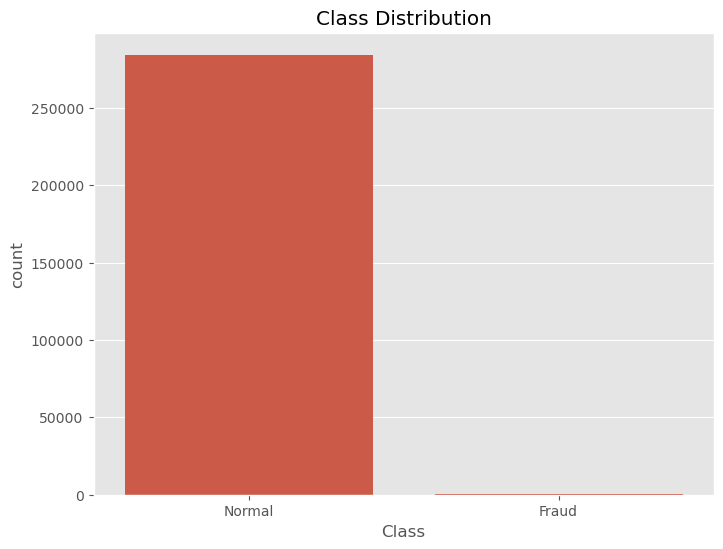

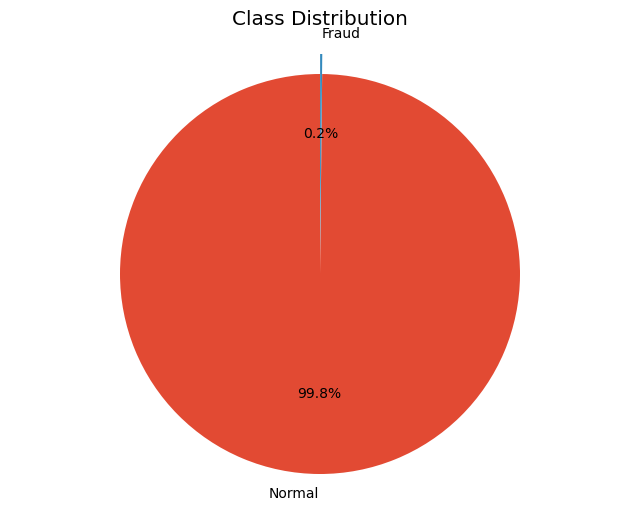

In [8]:
# Check class distribution
class_counts = df['Class'].value_counts()
print(f"Normal transactions: {class_counts[0]}")
print(f"Fraudulent transactions: {class_counts[1]}")
print(f"Percentage of fraud: {class_counts[1]/len(df)*100:.3f}%")

# Visualize class imbalance
plt.figure(figsize=(8, 6))
sns.countplot(x='Class', data=df)
plt.title('Class Distribution')
plt.xticks([0, 1], ['Normal', 'Fraud'])
plt.show()

# For better visualization of the imbalance
plt.figure(figsize=(8, 6))
labels = ['Normal', 'Fraud']
plt.pie(class_counts, labels=labels, autopct='%1.1f%%', startangle=90, explode=[0, 0.1])
plt.title('Class Distribution')
plt.axis('equal')
plt.show()

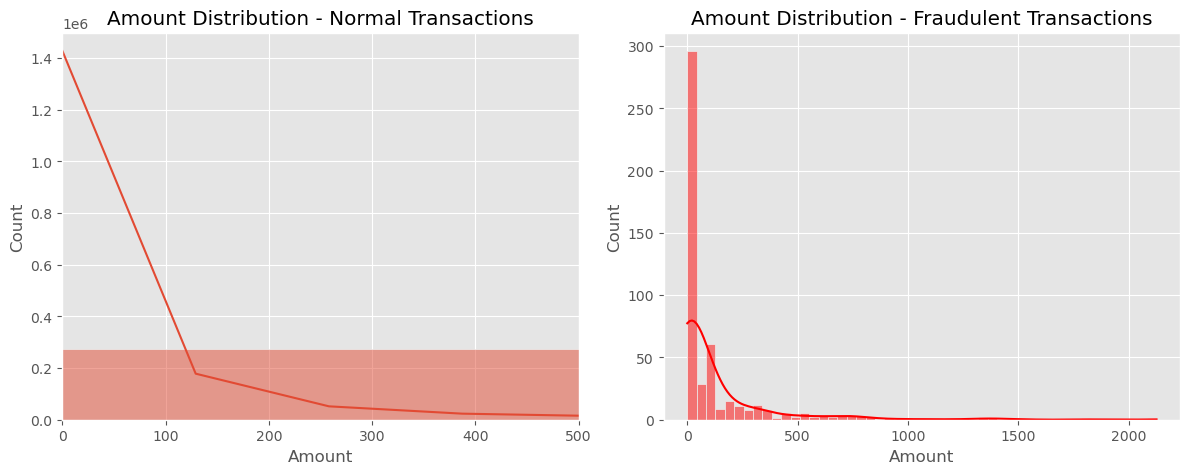

In [9]:
# Analyze transaction amount by class
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df[df['Class'] == 0]['Amount'], bins=50, kde=True)
plt.title('Amount Distribution - Normal Transactions')
plt.xlim([0, 500])

plt.subplot(1, 2, 2)
sns.histplot(df[df['Class'] == 1]['Amount'], bins=50, kde=True, color='red')
plt.title('Amount Distribution - Fraudulent Transactions')

plt.tight_layout()
plt.show()

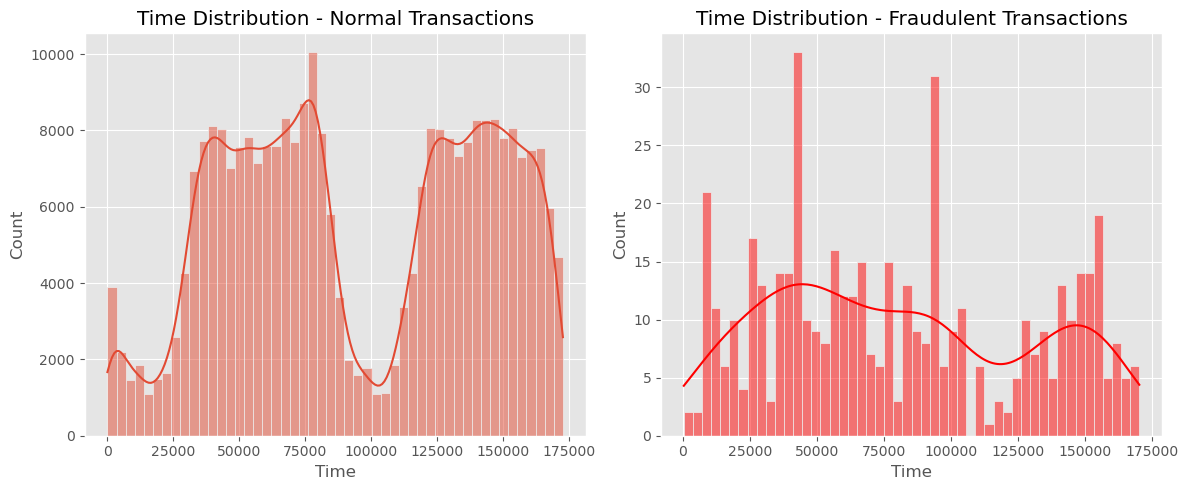

In [10]:
# Analyze transaction time by class
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df[df['Class'] == 0]['Time'], bins=50, kde=True)
plt.title('Time Distribution - Normal Transactions')

plt.subplot(1, 2, 2)
sns.histplot(df[df['Class'] == 1]['Time'], bins=50, kde=True, color='red')
plt.title('Time Distribution - Fraudulent Transactions')

plt.tight_layout()
plt.show()

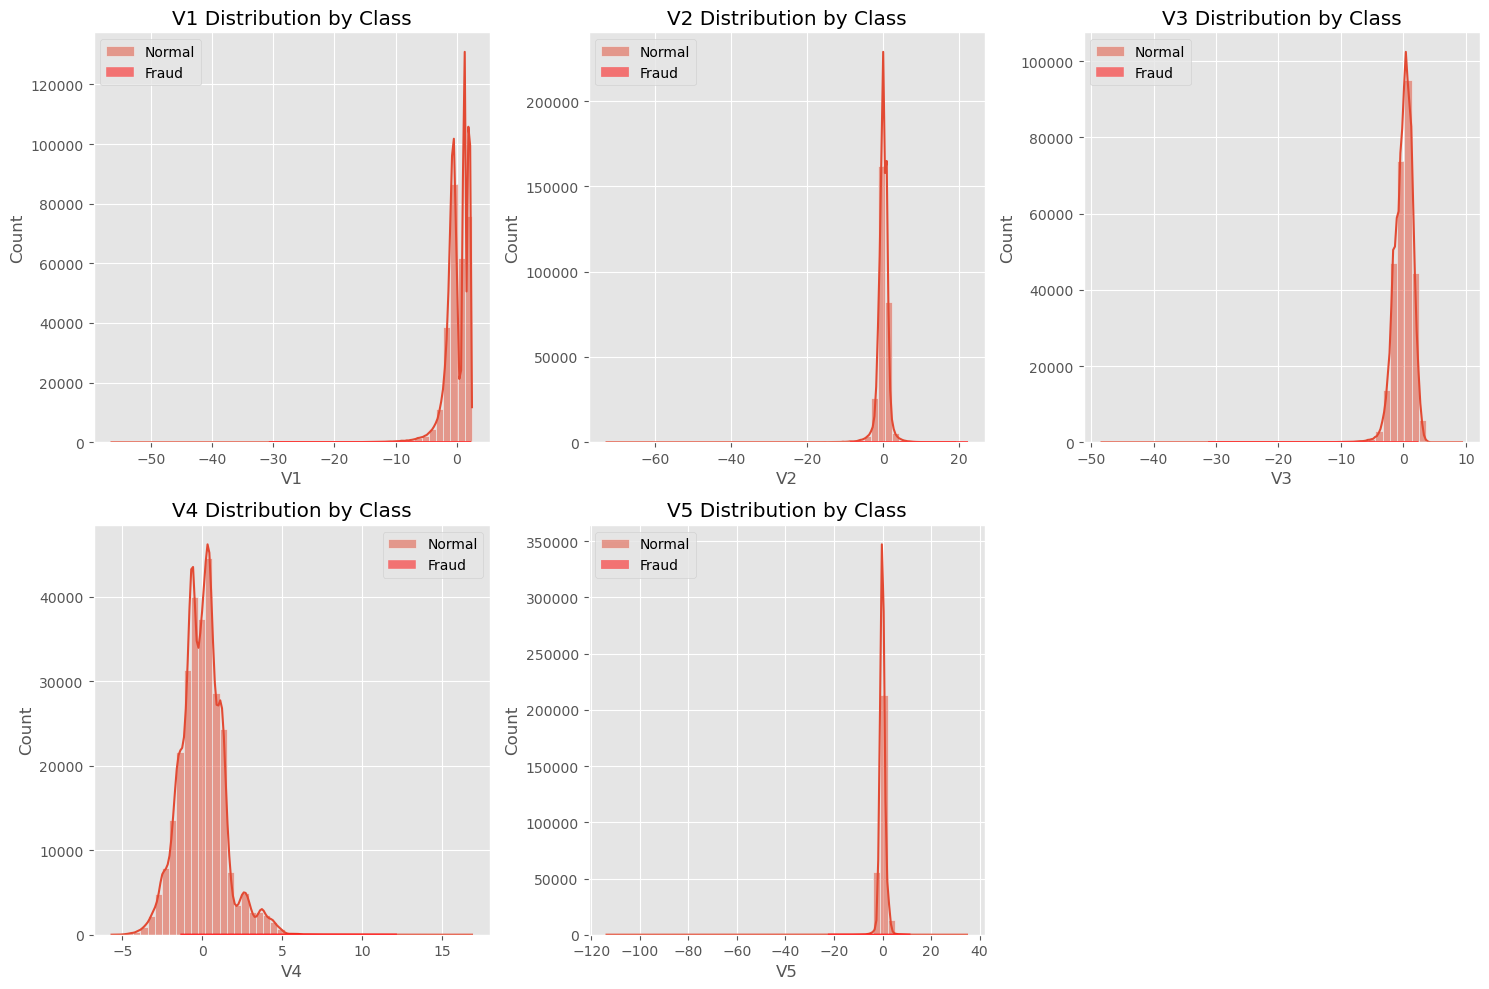

In [11]:
# Analyze the anonymized features (V1-V28)
# Let's look at the distribution of a few key features

# Select a subset of features for visualization
features = ['V1', 'V2', 'V3', 'V4', 'V5']

plt.figure(figsize=(15, 10))
for i, feature in enumerate(features):
    plt.subplot(2, 3, i+1)
    sns.histplot(df[df['Class'] == 0][feature], bins=50, kde=True, alpha=0.5, label='Normal')
    sns.histplot(df[df['Class'] == 1][feature], bins=50, kde=True, alpha=0.5, color='red', label='Fraud')
    plt.title(f'{feature} Distribution by Class')
    plt.legend()

plt.tight_layout()
plt.show()

Top 10 features correlated with Class:
Class     1.000000
V11       0.154876
V4        0.133447
V2        0.091289
V21       0.040413
V19       0.034783
V20       0.020090
V8        0.019875
V27       0.017580
V28       0.009536
Amount    0.005632
Name: Class, dtype: float64


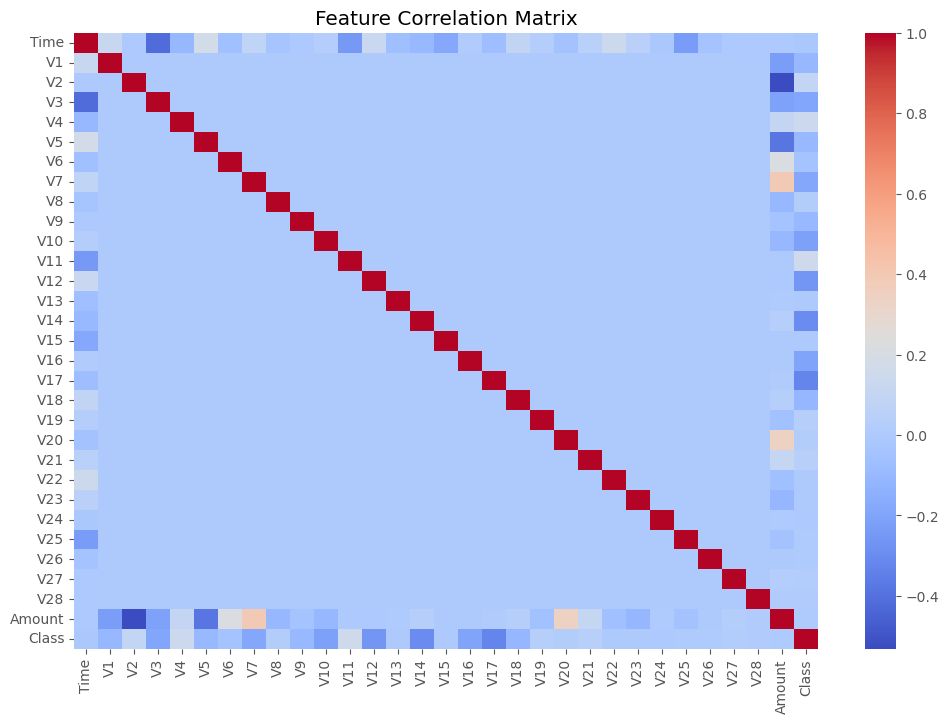

In [12]:
# Correlation analysis
# Let's see which features are most correlated with the Class

# Calculate correlation with Class
correlations = df.corr()['Class'].sort_values(ascending=False)
print("Top 10 features correlated with Class:")
print(correlations.head(11))  # 11 because Class itself will be included

# Visualize correlations
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), cmap='coolwarm', annot=False)
plt.title('Feature Correlation Matrix')
plt.show()

## 4. Data Preprocessing

Let's prepare the data for modeling.

In [14]:
# Separate features and target
X = df.drop('Class', axis=1)
y = df['Class']

# Scale the Amount and Time features
scaler = StandardScaler()
X['Amount'] = scaler.fit_transform(X['Amount'].values.reshape(-1, 1))
X['Time'] = scaler.fit_transform(X['Time'].values.reshape(-1, 1))

In [15]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")
print(f"Fraud cases in training set: {sum(y_train)}")
print(f"Fraud cases in testing set: {sum(y_test)}")

Training set shape: (227845, 30)
Testing set shape: (56962, 30)
Fraud cases in training set: 394
Fraud cases in testing set: 98


## 5. Handling Class Imbalance

We'll use different techniques to address the severe class imbalance in our dataset.

In [16]:
# Function to evaluate and visualize model performance
def evaluate_model(model, X_test, y_test, model_name):
    # Predict
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    
    # Classification Report
    cr = classification_report(y_test, y_pred)
    
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    
    # Precision-Recall Curve
    precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
    pr_auc = auc(recall, precision)
    
    # Visualize results
    plt.figure(figsize=(15, 10))
    
    # Confusion Matrix
    plt.subplot(2, 2, 1)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    
    # ROC Curve
    plt.subplot(2, 2, 2)
    plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - {model_name}')
    plt.legend()
    
    # Precision-Recall Curve
    plt.subplot(2, 2, 3)
    plt.plot(recall, precision, label=f'PR AUC = {pr_auc:.3f}')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Precision-Recall Curve - {model_name}')
    plt.legend()
    
    # Classification Report
    plt.subplot(2, 2, 4)
    plt.text(0.1, 0.5, cr, fontsize=12, family='monospace')
    plt.axis('off')
    plt.title(f'Classification Report - {model_name}')
    
    plt.tight_layout()
    plt.show()
    
    return {
        'confusion_matrix': cm,
        'classification_report': cr,
        'roc_auc': roc_auc,
        'pr_auc': pr_auc
    }

### 5.1 Baseline Model (Without Handling Imbalance)

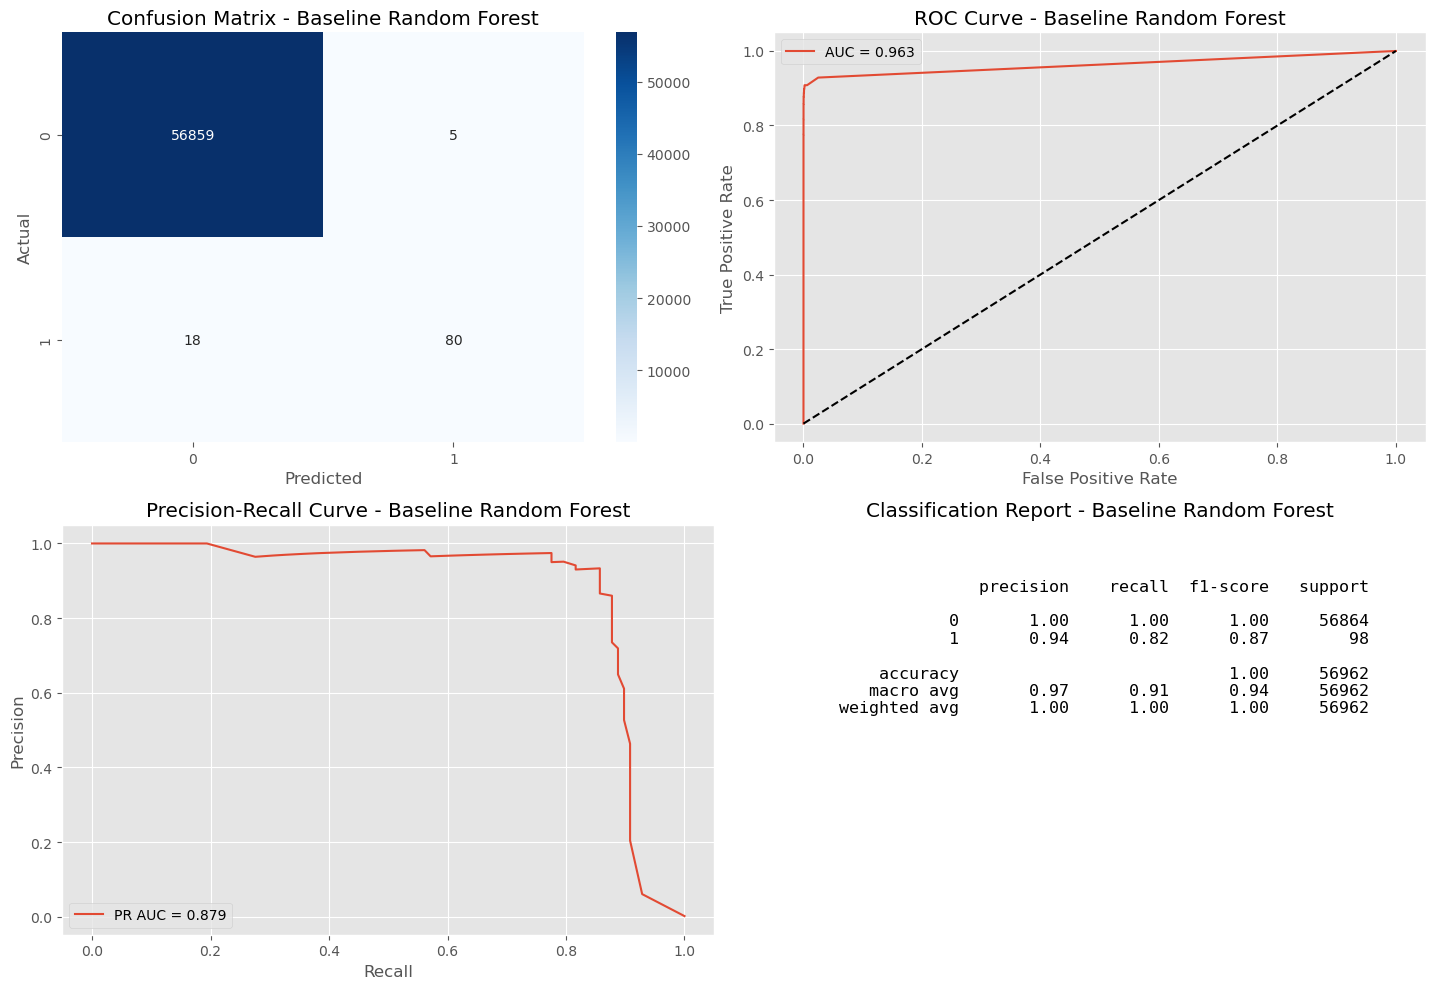

In [17]:
# Train a baseline model without handling imbalance
baseline_model = RandomForestClassifier(random_state=42)
baseline_model.fit(X_train, y_train)

# Evaluate baseline model
baseline_results = evaluate_model(baseline_model, X_test, y_test, 'Baseline Random Forest')

### 5.2 Using SMOTE (Synthetic Minority Over-sampling Technique)

In [18]:
# Apply SMOTE to handle imbalance
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"Original training set shape: {X_train.shape}")
print(f"Resampled training set shape: {X_train_smote.shape}")
print(f"Original class distribution: {pd.Series(y_train).value_counts()}")
print(f"Resampled class distribution: {pd.Series(y_train_smote).value_counts()}")

Original training set shape: (227845, 30)
Resampled training set shape: (454902, 30)
Original class distribution: Class
0    227451
1       394
Name: count, dtype: int64
Resampled class distribution: Class
0    227451
1    227451
Name: count, dtype: int64


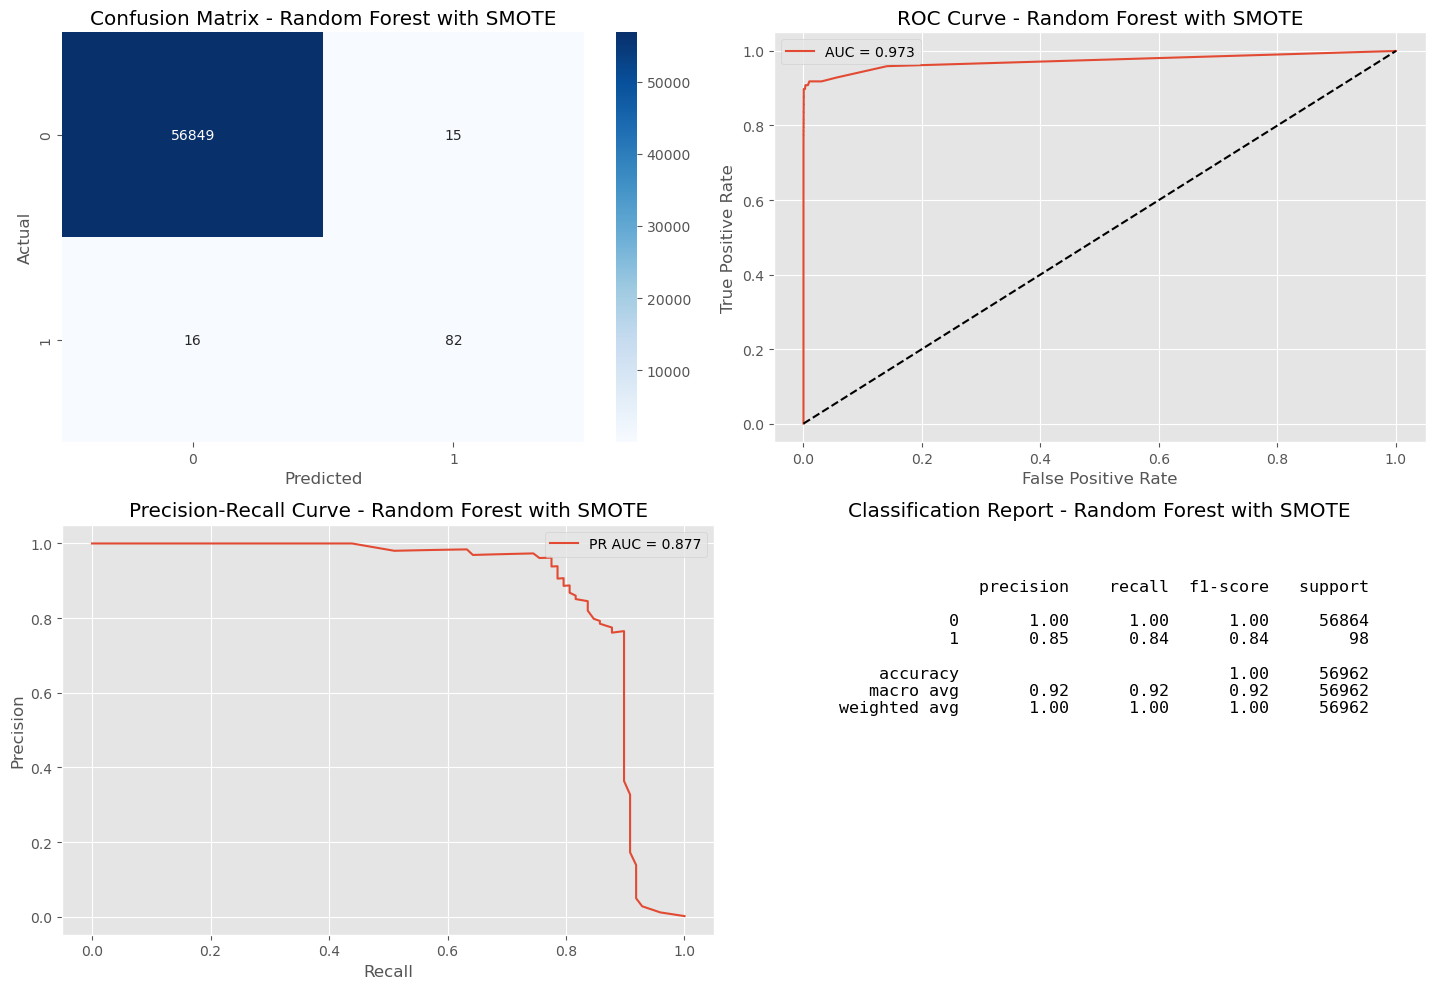

In [19]:
# Train model with SMOTE
smote_model = RandomForestClassifier(random_state=42)
smote_model.fit(X_train_smote, y_train_smote)

# Evaluate SMOTE model
smote_results = evaluate_model(smote_model, X_test, y_test, 'Random Forest with SMOTE')

### 5.3 Using Undersampling

In [20]:
# Apply undersampling
undersampler = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = undersampler.fit_resample(X_train, y_train)

print(f"Original training set shape: {X_train.shape}")
print(f"Undersampled training set shape: {X_train_under.shape}")
print(f"Original class distribution: {pd.Series(y_train).value_counts()}")
print(f"Undersampled class distribution: {pd.Series(y_train_under).value_counts()}")

Original training set shape: (227845, 30)
Undersampled training set shape: (788, 30)
Original class distribution: Class
0    227451
1       394
Name: count, dtype: int64
Undersampled class distribution: Class
0    394
1    394
Name: count, dtype: int64


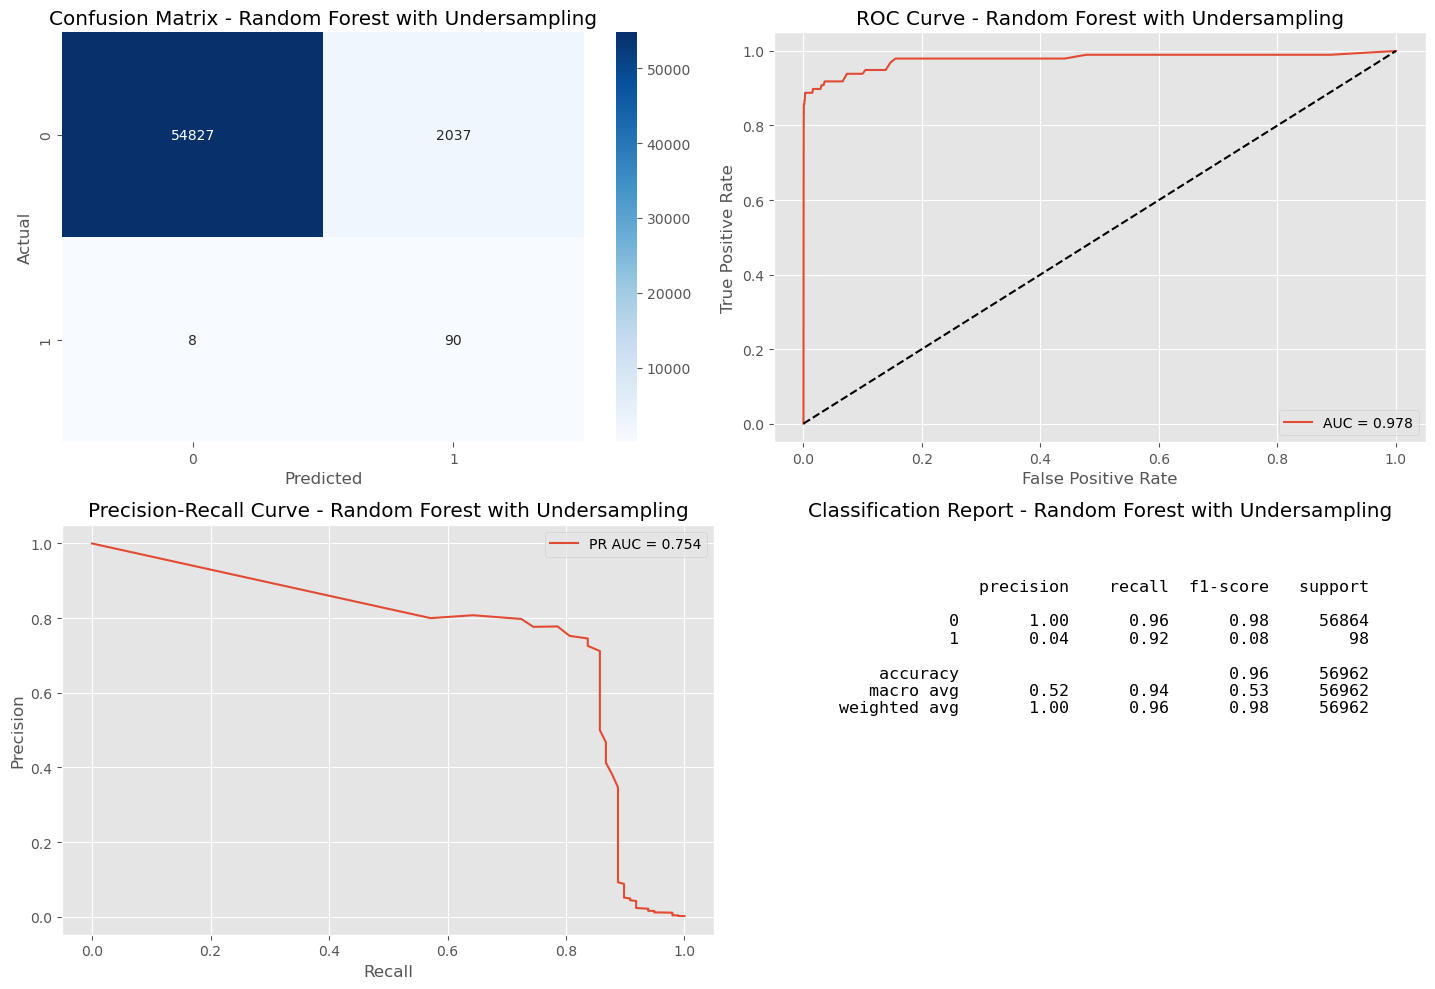

In [21]:
# Train model with undersampling
under_model = RandomForestClassifier(random_state=42)
under_model.fit(X_train_under, y_train_under)

# Evaluate undersampling model
under_results = evaluate_model(under_model, X_test, y_test, 'Random Forest with Undersampling')

## 6. Advanced Model Training

Let's try different algorithms and tune hyperparameters.

### 6.1 Logistic Regression with Class Weights

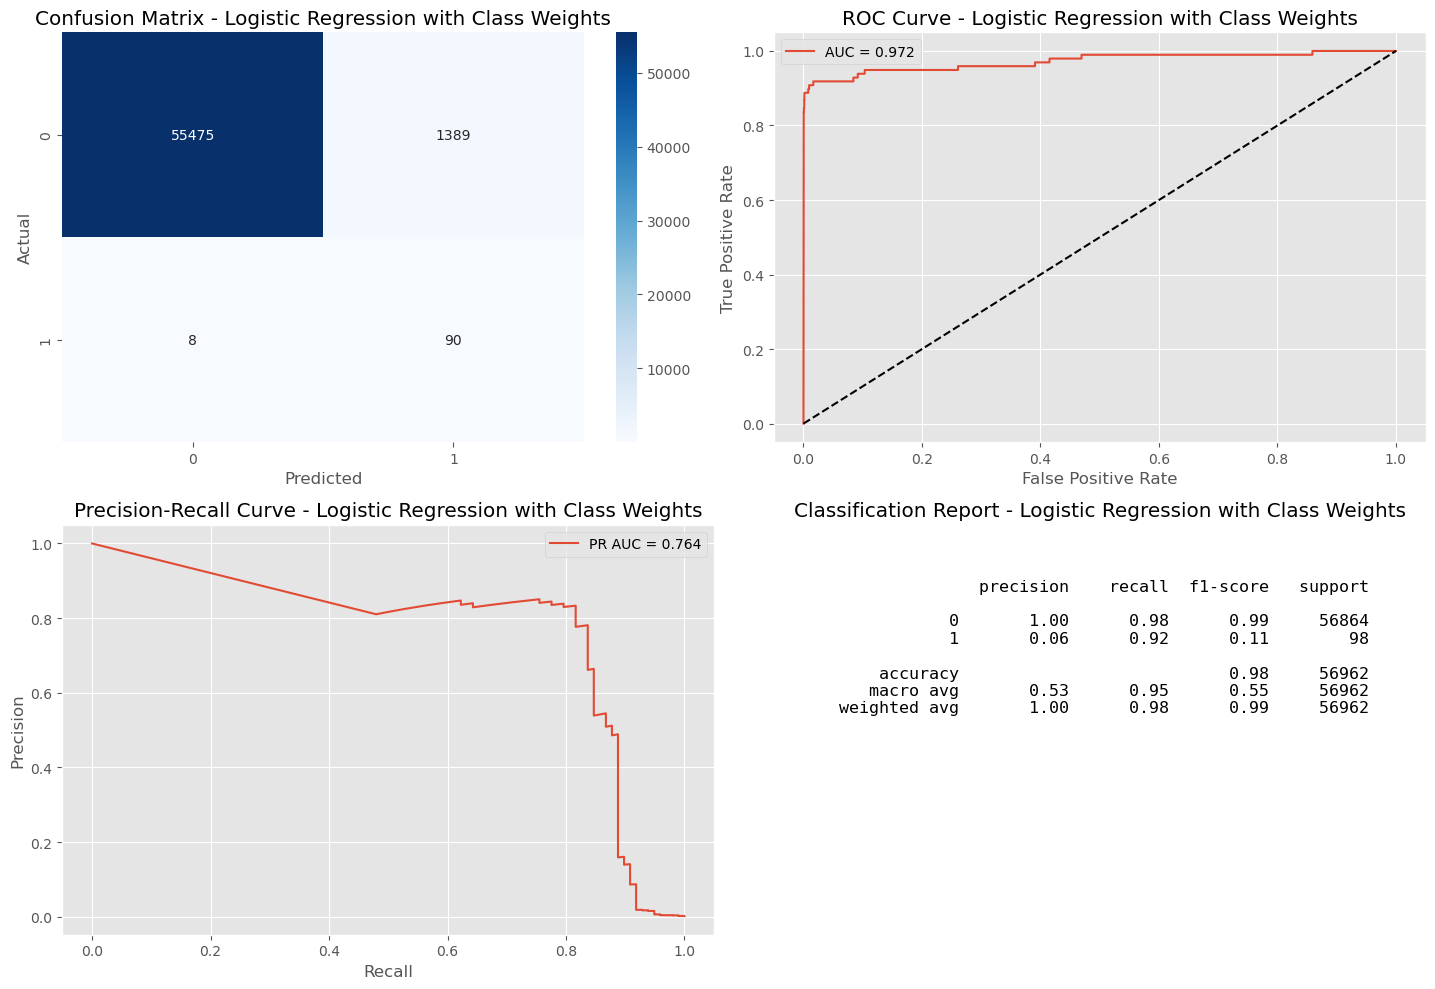

In [22]:
# Train Logistic Regression with class weights
lr_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

# Evaluate Logistic Regression model
lr_results = evaluate_model(lr_model, X_test, y_test, 'Logistic Regression with Class Weights')

### 6.2 XGBoost with Scale Pos Weight

Scale Pos Weight: 577.2868020304569


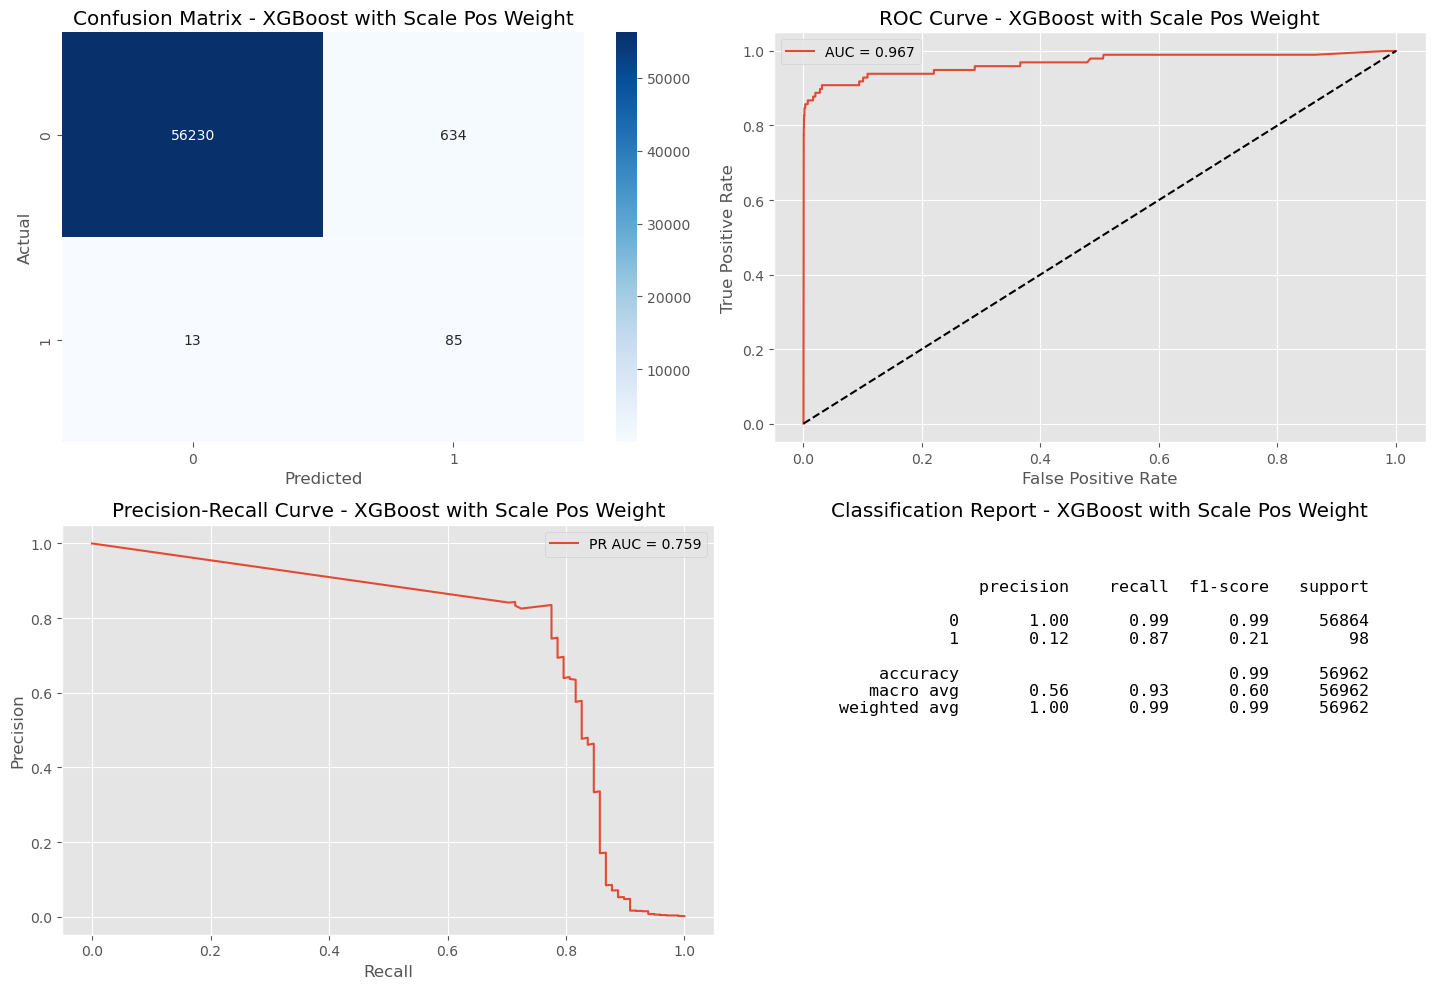

In [23]:
# Calculate the scale_pos_weight
scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])
print(f"Scale Pos Weight: {scale_pos_weight}")

# Train XGBoost with scale_pos_weight
xgb_model = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    learning_rate=0.01,
    n_estimators=200,
    max_depth=4,
    random_state=42
)
xgb_model.fit(X_train, y_train)

# Evaluate XGBoost model
xgb_results = evaluate_model(xgb_model, X_test, y_test, 'XGBoost with Scale Pos Weight')

### 6.3 Gradient Boosting with Hyperparameter Tuning

Best parameters: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 200}
Best F1 score: 0.998


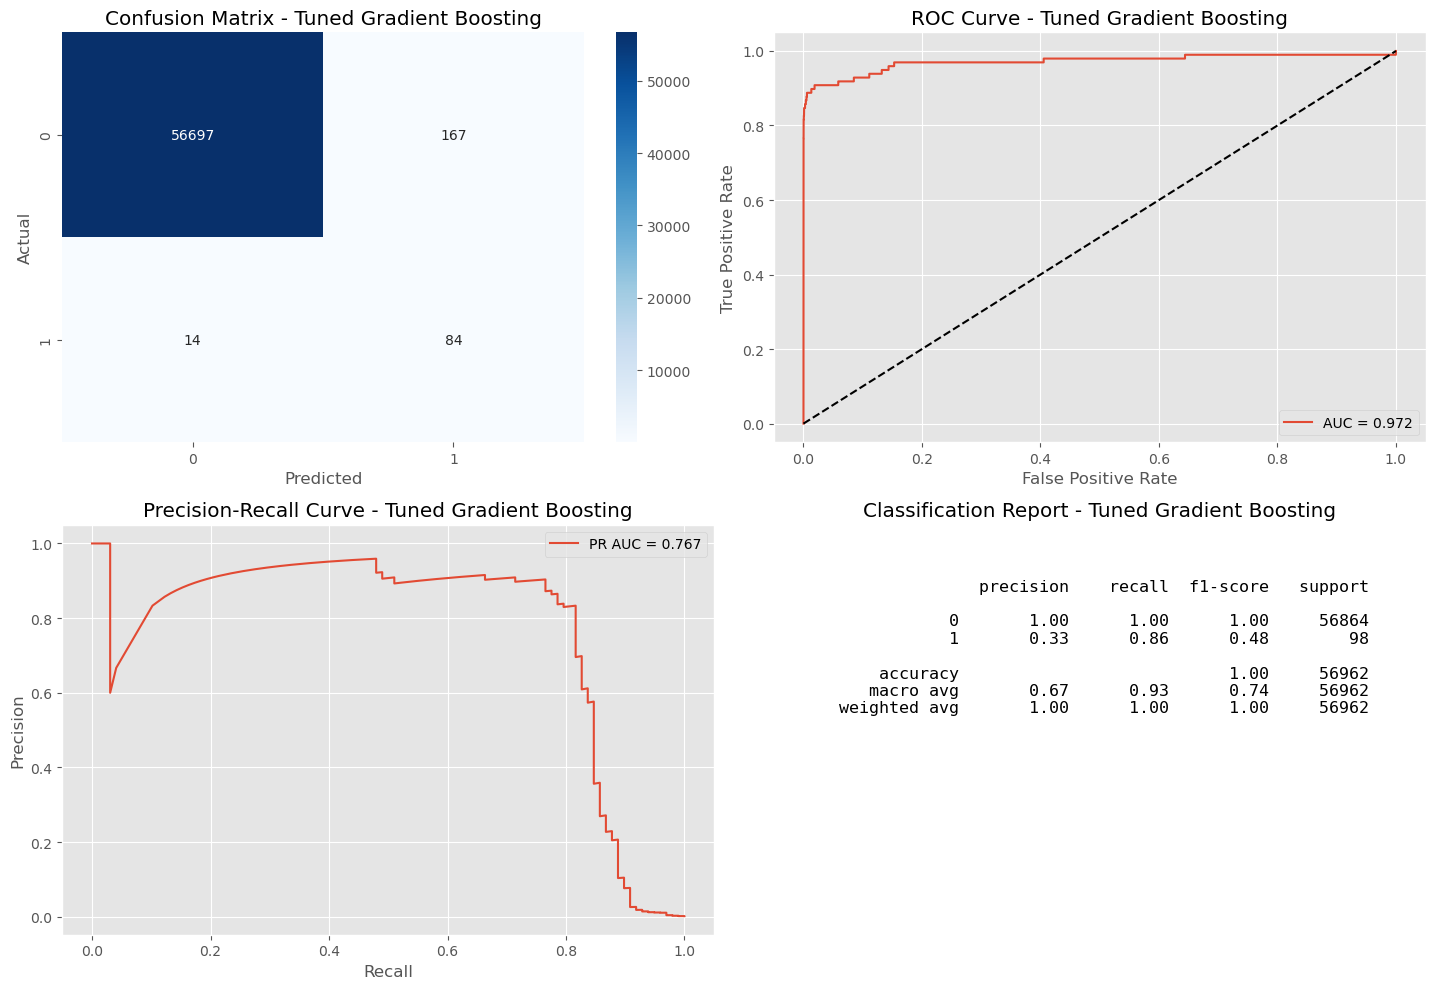

In [25]:
# Define parameter grid for GridSearchCV
param_grid = {
    'learning_rate': [0.01, 0.1],
    'n_estimators': [100, 200],
    'max_depth': [3, 4]
}

# Create base model
gb_base = GradientBoostingClassifier(random_state=42)

# Perform grid search with cross-validation
grid_search = GridSearchCV(
    estimator=gb_base,
    param_grid=param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

# Fit grid search to SMOTE-resampled data for better performance on minority class
grid_search.fit(X_train_smote, y_train_smote)

# Get best parameters
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best F1 score: {grid_search.best_score_:.3f}")

# Evaluate best model
gb_results = evaluate_model(grid_search.best_estimator_, X_test, y_test, 'Tuned Gradient Boosting')

## 7. Threshold Optimization

Let's optimize the classification threshold to better balance precision and recall.

Default threshold: 0.5
Optimal threshold: 0.925
Optimal F1 score: 0.804


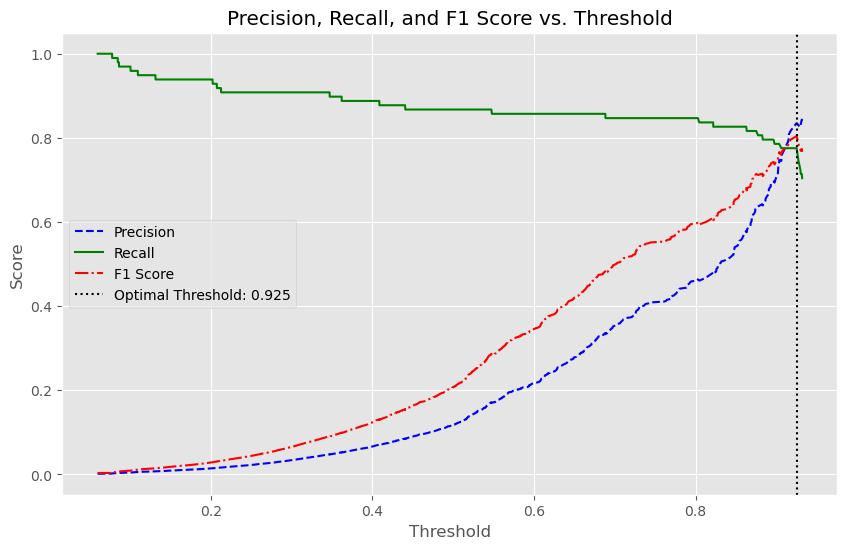

In [ ]:
# Get the best model 
best_model = xgb_model

# Get predicted probabilities
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

# Calculate precision and recall for different thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)

# Calculate F1 score for each threshold
f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1])

# Find the threshold that maximizes F1 score
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]
optimal_f1 = f1_scores[optimal_idx]

print(f"Default threshold: 0.5")
print(f"Optimal threshold: {optimal_threshold:.3f}")
print(f"Optimal F1 score: {optimal_f1:.3f}")

# Plot precision-recall curve with threshold
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precision[:-1], 'b--', label='Precision')
plt.plot(thresholds, recall[:-1], 'g-', label='Recall')
plt.plot(thresholds, f1_scores, 'r-.', label='F1 Score')
plt.axvline(x=optimal_threshold, color='k', linestyle=':', label=f'Optimal Threshold: {optimal_threshold:.3f}')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision, Recall, and F1 Score vs. Threshold')
plt.legend()
plt.grid(True)
plt.show()

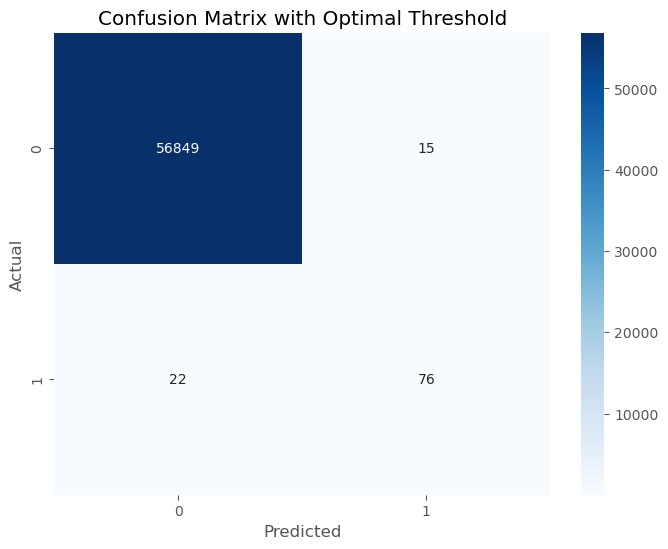

Classification Report with Optimal Threshold:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.84      0.78      0.80        98

    accuracy                           1.00     56962
   macro avg       0.92      0.89      0.90     56962
weighted avg       1.00      1.00      1.00     56962



In [27]:
# Apply the optimal threshold
y_pred_optimal = (y_pred_proba >= optimal_threshold).astype(int)

# Calculate confusion matrix with optimal threshold
cm_optimal = confusion_matrix(y_test, y_pred_optimal)

# Display confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_optimal, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix with Optimal Threshold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Display classification report
print("Classification Report with Optimal Threshold:")
print(classification_report(y_test, y_pred_optimal))

## 8. Feature Importance Analysis

Let's analyze which features are most important for fraud detection.

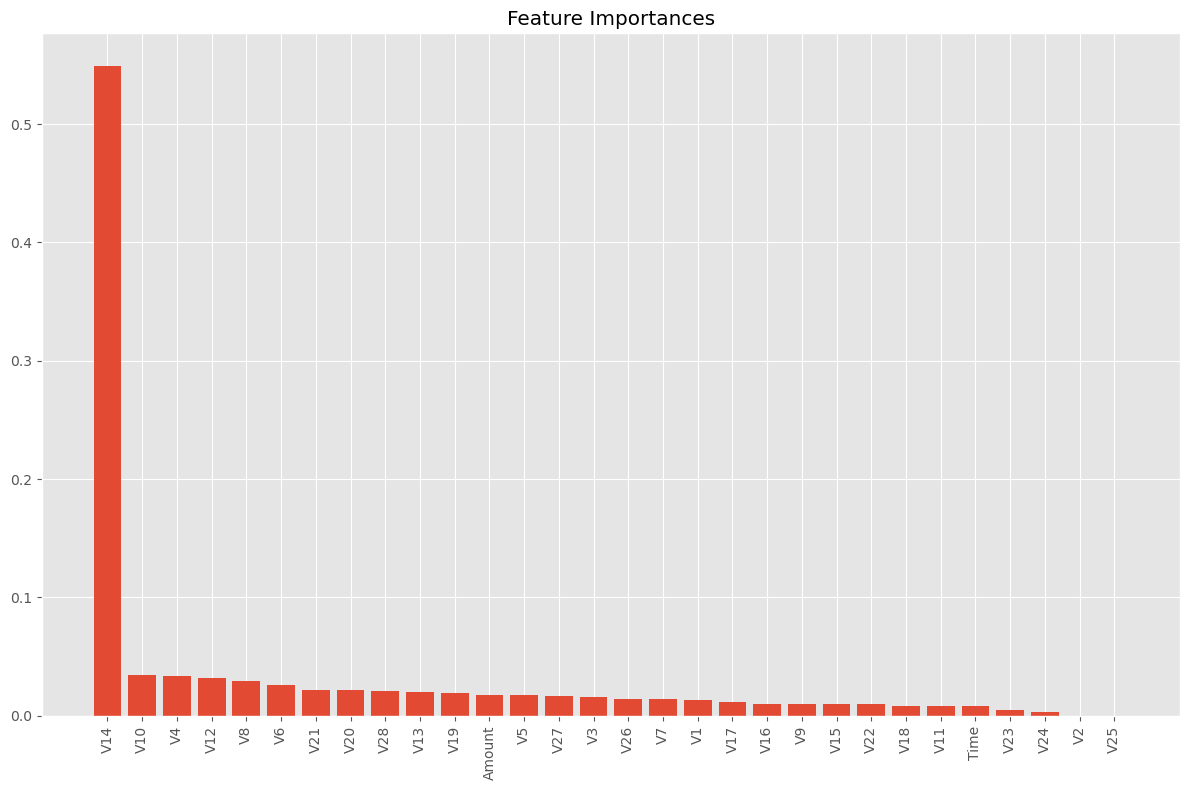

Top 10 most important features:
1. V14: 0.5492
2. V10: 0.0343
3. V4: 0.0338
4. V12: 0.0318
5. V8: 0.0293
6. V6: 0.0259
7. V21: 0.0216
8. V20: 0.0214
9. V28: 0.0212
10. V13: 0.0198


In [28]:
# Get feature importances from the best model
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    feature_names = X.columns
    
    # Sort feature importances
    indices = np.argsort(importances)[::-1]
    
    # Plot feature importances
    plt.figure(figsize=(12, 8))
    plt.title('Feature Importances')
    plt.bar(range(len(indices)), importances[indices], align='center')
    plt.xticks(range(len(indices)), [feature_names[i] for i in indices], rotation=90)
    plt.tight_layout()
    plt.show()
    
    # Print top 10 features
    print("Top 10 most important features:")
    for i in range(10):
        print(f"{i+1}. {feature_names[indices[i]]}: {importances[indices[i]]:.4f}")
else:
    print("This model doesn't provide feature importances directly.")

## 9. Model Comparison and Final Selection

Let's compare all the models we've trained and select the best one.

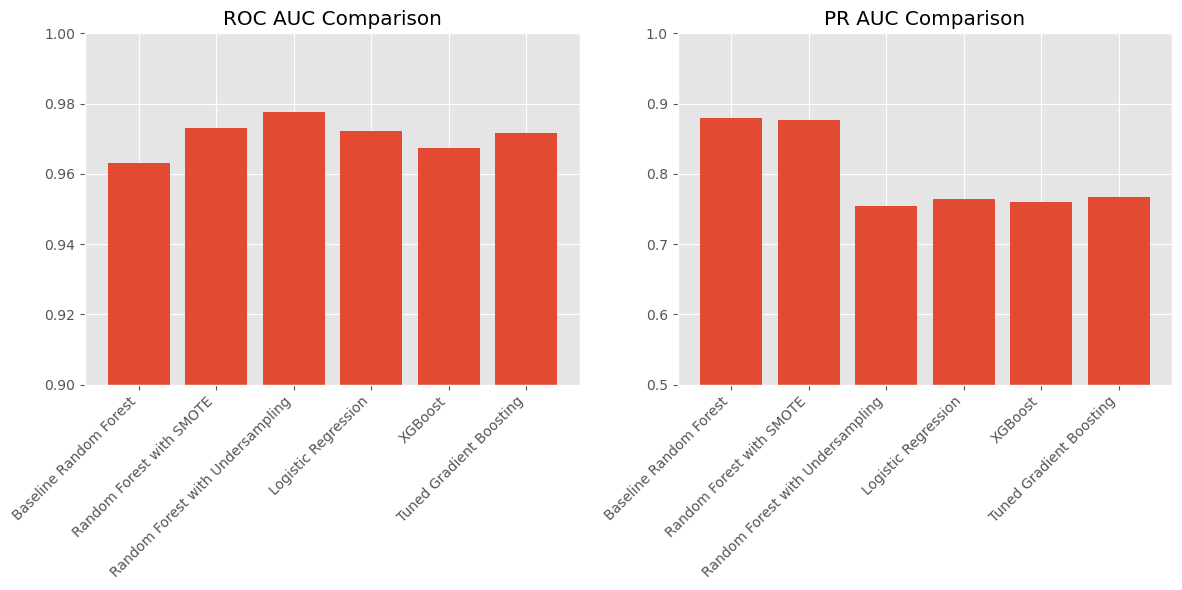

In [29]:
# Collect results from all models
models = {
    'Baseline Random Forest': baseline_results,
    'Random Forest with SMOTE': smote_results,
    'Random Forest with Undersampling': under_results,
    'Logistic Regression': lr_results,
    'XGBoost': xgb_results,
    'Tuned Gradient Boosting': gb_results
}

# Compare ROC AUC and PR AUC
roc_aucs = {name: results['roc_auc'] for name, results in models.items()}
pr_aucs = {name: results['pr_auc'] for name, results in models.items()}

# Plot comparison
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.bar(roc_aucs.keys(), roc_aucs.values())
plt.title('ROC AUC Comparison')
plt.xticks(rotation=45, ha='right')
plt.ylim(0.9, 1.0)  # Adjust as needed

plt.subplot(1, 2, 2)
plt.bar(pr_aucs.keys(), pr_aucs.values())
plt.title('PR AUC Comparison')
plt.xticks(rotation=45, ha='right')
plt.ylim(0.5, 1.0)  # Adjust as needed

plt.tight_layout()
plt.show()

## 10. Real-time Fraud Detection System

Let's create a simple function to simulate a real-time fraud detection system.

In [30]:
# Function to detect fraud in real-time
def detect_fraud(transaction, model, threshold=0.5):
    """
    Detect if a transaction is fraudulent.
    
    Parameters:
    transaction (dict): Transaction data with keys matching the feature names
    model: Trained model
    threshold (float): Classification threshold
    
    Returns:
    dict: Detection results
    """
    # Convert transaction to DataFrame
    transaction_df = pd.DataFrame([transaction])
    
    # Scale Amount and Time
    if 'Amount' in transaction_df.columns:
        transaction_df['Amount'] = scaler.transform(transaction_df['Amount'].values.reshape(-1, 1))
    if 'Time' in transaction_df.columns:
        transaction_df['Time'] = scaler.transform(transaction_df['Time'].values.reshape(-1, 1))
    
    # Ensure all model features are present
    for col in X.columns:
        if col not in transaction_df.columns:
            transaction_df[col] = 0
    
    # Reorder columns to match training data
    transaction_df = transaction_df[X.columns]
    
    # Get fraud probability
    fraud_prob = model.predict_proba(transaction_df)[0, 1]
    
    # Make prediction based on threshold
    is_fraud = fraud_prob >= threshold
    
    return {
        'is_fraud': bool(is_fraud),
        'fraud_probability': float(fraud_prob),
        'threshold': threshold,
        'timestamp': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')
    }

## 11. Conclusion and Next Steps

In this notebook, we've built a machine learning model to detect credit card fraud. Here's a summary of what we've learned:

1. **Data Exploration**: We analyzed the highly imbalanced dataset with only 0.172% fraud cases.
2. **Feature Analysis**: We examined the anonymized features and their relationship with fraud.
3. **Handling Imbalance**: We tried different techniques like SMOTE, undersampling, and class weights.
4. **Model Training**: We trained and compared multiple models including Random Forest, Logistic Regression, XGBoost, and Gradient Boosting.
5. **Threshold Optimization**: We found an optimal threshold to balance precision and recall.
6. **Feature Importance**: We identified the most important features for fraud detection.
7. **Real-time Detection**: We created a function to simulate real-time fraud detection.

### Next Steps:

1. **Model Deployment**: Deploy the model in a production environment.
2. **Monitoring**: Set up monitoring to track model performance over time.
3. **Feedback Loop**: Implement a feedback mechanism to continuously improve the model.
4. **Cost-sensitive Learning**: Incorporate the cost of false positives vs. false negatives.
5. **Ensemble Methods**: Try combining multiple models for better performance.
6. **Deep Learning**: Explore neural network approaches for fraud detection.